c:\Users\adamm\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9260 - loss: 0.2590 - val_accuracy: 0.9584 - val_loss: 0.1420
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9672 - loss: 0.1120 - val_accuracy: 0.9698 - val_loss: 0.0955
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9768 - loss: 0.0785 - val_accuracy: 0.9753 - val_loss: 0.0785
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9825 - loss: 0.0577 - val_accuracy: 0.9756 - val_loss: 0.0755
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9859 - loss: 0.0449 - val_accuracy: 0.9770 - val_loss: 0.0734
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9894 - loss: 0.0345 - val_accuracy: 0.9766 - val_loss: 0.0746
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9913 - loss: 0.0282 - val_accuracy: 0.9741 - val_loss: 0.0898
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9930 - loss: 0.0231 -

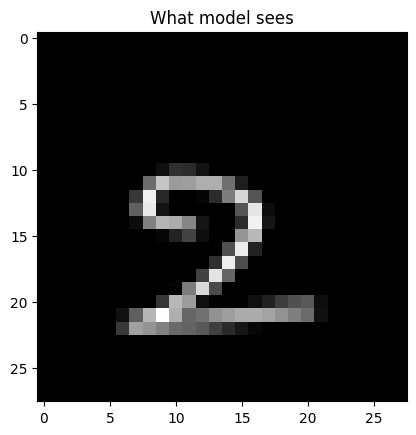

Min: 0
Max: 245
Shape: (28, 28)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Predicted digit: 8


In [28]:
import tensorflow as tf
from tensorflow import keras
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


mnist = keras.datasets.mnist

(train_data,train_labels),(test_data,test_labels) = mnist.load_data()

train_data = train_data/255
test_data = test_data/255

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(128,activation="relu"),
    keras.layers.Dense(10,activation="softmax")
])

model.compile(optimizer='adam' , loss = "sparse_categorical_crossentropy",metrics=["accuracy"])

model.fit(train_data,train_labels,epochs=10,validation_data=(test_data, test_labels))

test_loss,test_acc = model.evaluate(test_data,test_labels)

img = Image.open("Untitled.png")
img = img.convert("L")
img = img.resize((28,28))
img_array = np.array(img)

plt.imshow(img_array, cmap='gray')
plt.title('What model sees')
plt.show()

print("Min:", img_array.min())
print("Max:", img_array.max())
print("Shape:", img_array.shape)

img_array = img_array/255

img_array=img_array.reshape(1,28,28)

prediction = model.predict(img_array)
print("Predicted digit:", np.argmax(prediction))




In [25]:
model.save('mnist_model.h5')
plt.imsave('mnist_9.png', test_data[1], cmap='gray')